# 04 — Centrality Analysis

This notebook computes the main centrality measures used to study different forms of importance in the citation network.

The goal is to move beyond simple degree counts and distinguish between:

- **citation popularity**: papers that receive many citations;
- **citation prestige**: papers that are cited by important papers;
- **brokerage**: papers that lie on many paths between other papers.

The notebook uses the cleaned edge list produced in Notebook 01 and the node degree table produced in Notebook 03.

## 1. Imports and project paths

The notebooks are stored inside the `notebooks/` folder.  
For this reason, the project root is detected automatically.

In [22]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
CENTRALITY_OUTPUT_DIR = OUTPUT_DIR / "centrality_analysis"

CENTRALITY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_EDGES_PATH = PROCESSED_DIR / "cit_hepth_clean_edges.parquet"
NODE_DEGREES_PATH = PROCESSED_DIR / "cit_hepth_node_degrees.parquet"

print(f"Current directory: {CURRENT_DIR}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Cleaned edges path exists: {CLEAN_EDGES_PATH.exists()}")
print(f"Node degrees path exists: {NODE_DEGREES_PATH.exists()}")

Current directory: /Users/chiarabelli/Desktop/citation-network-project/notebooks
Project root: /Users/chiarabelli/Desktop/citation-network-project
Cleaned edges path exists: True
Node degrees path exists: True


## 2. Spark session

Spark is used here to load the preprocessed Parquet files and perform basic checks before converting the data to pandas/NetworkX.

In [3]:
spark = (
    SparkSession.builder
    .appName("CitHepThCentralityAnalysis")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/15 16:35:15 WARN Utils: Your hostname, MacBook-Pro-di-Chiara.local, resolves to a loopback address: 127.0.0.1; using 10.208.162.29 instead (on interface en0)
26/05/15 16:35:15 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/15 16:35:16 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 3. Load cleaned edges and node degrees

The cleaned edge list uses the following schema:

- `from_node_id`: paper that cites another paper;
- `to_node_id`: paper that is cited.

The node degree table was created in Notebook 03 and contains:

- `node_id`;
- `in_degree`;
- `out_degree`;
- `total_degree`.

In [4]:
if not CLEAN_EDGES_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned edge list not found at: {CLEAN_EDGES_PATH}\n"
        "Please run Notebook 01 first."
    )

if not NODE_DEGREES_PATH.exists():
    raise FileNotFoundError(
        f"Node degree table not found at: {NODE_DEGREES_PATH}\n"
        "Please run Notebook 03 first."
    )

edges_sdf = spark.read.parquet(str(CLEAN_EDGES_PATH))
node_degrees_sdf = spark.read.parquet(str(NODE_DEGREES_PATH))

print("Edges schema:")
edges_sdf.printSchema()

print("Node degrees schema:")
node_degrees_sdf.printSchema()

Edges schema:
root
 |-- from_node_id: long (nullable = true)
 |-- to_node_id: long (nullable = true)

Node degrees schema:
root
 |-- node_id: long (nullable = true)
 |-- in_degree: long (nullable = true)
 |-- out_degree: long (nullable = true)
 |-- total_degree: long (nullable = true)



In [5]:
required_edge_columns = {"from_node_id", "to_node_id"}
required_degree_columns = {"node_id", "in_degree", "out_degree", "total_degree"}

missing_edge_columns = required_edge_columns - set(edges_sdf.columns)
missing_degree_columns = required_degree_columns - set(node_degrees_sdf.columns)

if missing_edge_columns:
    raise ValueError(f"Missing edge columns: {missing_edge_columns}")

if missing_degree_columns:
    raise ValueError(f"Missing degree columns: {missing_degree_columns}")

num_edges = edges_sdf.count()
num_nodes = node_degrees_sdf.count()

summary_pdf = pd.DataFrame(
    {
        "Metric": ["Number of nodes", "Number of directed edges"],
        "Value": [num_nodes, num_edges],
    }
)

display(
    summary_pdf.style
    .hide(axis="index")
    .format({"Value": "{:,}"})
)

Metric,Value
Number of nodes,"27,769"
Number of directed edges,"352,768"


## 4. Convert the edge list to NetworkX

The graph is converted to a `networkx.DiGraph`.

This is feasible for this dataset because the graph has around 27k nodes and 350k edges.  
Spark remains useful for scalable preprocessing, while NetworkX is more convenient for graph algorithms such as PageRank and centrality measures.

In [6]:
edges_pdf = edges_sdf.select("from_node_id", "to_node_id").toPandas()

G = nx.from_pandas_edgelist(
    edges_pdf,
    source="from_node_id",
    target="to_node_id",
    create_using=nx.DiGraph()
)

print(G)
print(f"Is directed: {G.is_directed()}")
print(f"Number of nodes: {G.number_of_nodes():,}")
print(f"Number of edges: {G.number_of_edges():,}")

DiGraph with 27769 nodes and 352768 edges
Is directed: True
Number of nodes: 27,769
Number of edges: 352,768


## 5. Degree centrality

Degree centrality normalizes degree by the maximum possible number of neighbors, which is \(n - 1\).

For a citation network:

- **in-degree centrality** measures normalized citation popularity;
- **out-degree centrality** measures normalized citation activity;
- **total-degree centrality** summarizes the overall local connectivity of a paper.

The raw degree counts were already computed in Notebook 03, so here they are normalized.

In [7]:
node_degrees_pdf = node_degrees_sdf.toPandas()

n = len(node_degrees_pdf)

node_degrees_pdf["in_degree_centrality"] = node_degrees_pdf["in_degree"] / (n - 1)
node_degrees_pdf["out_degree_centrality"] = node_degrees_pdf["out_degree"] / (n - 1)
node_degrees_pdf["total_degree_centrality"] = node_degrees_pdf["total_degree"] / (2 * (n - 1))

degree_centrality_pdf = node_degrees_pdf[
    [
        "node_id",
        "in_degree",
        "out_degree",
        "total_degree",
        "in_degree_centrality",
        "out_degree_centrality",
        "total_degree_centrality",
    ]
].copy()

display(
    degree_centrality_pdf
    .sort_values("in_degree", ascending=False)
    .head(10)
    .style
    .hide(axis="index")
    .format(
        {
            "node_id": "{:.0f}",
            "in_degree": "{:,}",
            "out_degree": "{:,}",
            "total_degree": "{:,}",
            "in_degree_centrality": "{:.6f}",
            "out_degree_centrality": "{:.6f}",
            "total_degree_centrality": "{:.6f}",
        }
    )
)

node_id,in_degree,out_degree,total_degree,in_degree_centrality,out_degree_centrality,total_degree_centrality
9711200,"2,414",54,"2,468",0.086935,0.001945,0.044440
9802150,"1,775",22,"1,797",0.063923,0.000792,0.032357
9802109,"1,641",12,"1,653",0.059097,0.000432,0.029764
9407087,"1,299",9,"1,308",0.046780,0.000324,0.023552
9610043,"1,199",19,"1,218",0.043179,0.000684,0.021932
9510017,"1,155",10,"1,165",0.041595,0.000360,0.020977
9908142,"1,144",75,"1,219",0.041199,0.002701,0.021950
9503124,"1,114",10,"1,124",0.040118,0.000360,0.020239
9906064,"1,032",6,"1,038",0.037165,0.000216,0.018691
9408099,"1,006",7,"1,013",0.036229,0.000252,0.018240


## 6. PageRank

PageRank measures citation prestige.

A paper receives high PageRank if it is cited by other papers that are themselves important.  
Therefore, PageRank is not only based on the number of citations received, but also on the quality or importance of the citing papers.

In this project, PageRank is interpreted as a measure of **citation prestige**.

In [8]:
start_time = time.time()

pagerank_dict = nx.pagerank(
    G,
    alpha=0.85,
    max_iter=100,
    tol=1e-06
)

elapsed_time = time.time() - start_time

pagerank_pdf = pd.DataFrame(
    {
        "node_id": list(pagerank_dict.keys()),
        "pagerank": list(pagerank_dict.values()),
    }
)

print(f"PageRank computed in {elapsed_time:.2f} seconds.")

display(
    pagerank_pdf
    .sort_values("pagerank", ascending=False)
    .head(10)
    .style
    .hide(axis="index")
    .format(
        {
            "node_id": "{:.0f}",
            "pagerank": "{:.8f}",
        }
    )
)

PageRank computed in 1.40 seconds.


node_id,pagerank
9407087,0.00624191
9503124,0.00463545
9510017,0.00438800
9402044,0.00393702
9711200,0.00341609
9410167,0.00340911
9408099,0.00319149
9207016,0.00311487
9402002,0.00296395
9610043,0.00275443


## 7. HITS authority and hub scores

The HITS algorithm provides two scores:

- **authority score**: high for papers cited by good hubs;
- **hub score**: high for papers that cite many good authorities.

In a citation network, authority is conceptually close to scientific importance, while hub score may identify papers that point to a broad or important set of previous works.

In [9]:
start_time = time.time()

try:
    hits_hubs, hits_authorities = nx.hits(
        G,
        max_iter=100,
        tol=1e-08,
        normalized=True
    )

    hits_pdf = pd.DataFrame(
        {
            "node_id": list(hits_authorities.keys()),
            "authority_score": list(hits_authorities.values()),
            "hub_score": [hits_hubs[node] for node in hits_authorities.keys()],
        }
    )

    elapsed_time = time.time() - start_time
    print(f"HITS computed in {elapsed_time:.2f} seconds.")

    display(
        hits_pdf
        .sort_values("authority_score", ascending=False)
        .head(10)
        .style
        .hide(axis="index")
        .format(
            {
                "node_id": "{:.0f}",
                "authority_score": "{:.8f}",
                "hub_score": "{:.8f}",
            }
        )
    )

except Exception as e:
    print("HITS did not converge or failed with the following error:")
    print(e)
    hits_pdf = pd.DataFrame({"node_id": list(G.nodes())})

HITS computed in 1.86 seconds.


node_id,authority_score,hub_score
9711200,0.01692836,0.00020026
9802150,0.01416189,0.00017037
9802109,0.01351012,0.00015804
9905111,0.00523606,0.00135256
9510017,0.00492623,0.00005579
9610043,0.00457250,0.00013227
9503124,0.00443275,0.00003467
9803131,0.00375065,0.00044070
9510135,0.00337507,0.00010645
9410167,0.00311440,0.00004050


## 8. Approximate betweenness centrality

Betweenness centrality measures how often a node lies on shortest paths between other nodes.

In this project, betweenness is interpreted as a measure of **brokerage**: a paper with high betweenness may connect different areas of the citation network.

Exact betweenness centrality can be computationally expensive on large graphs.  
For this reason, we use the approximation implemented in NetworkX, based on a sample of source nodes.

The parameter `BETWEENNESS_SAMPLE_SIZE` can be increased for higher accuracy or decreased for faster execution.

In [10]:
BETWEENNESS_SAMPLE_SIZE = 500
RANDOM_SEED = 42

print(f"Number of nodes: {G.number_of_nodes():,}")
print(f"Betweenness sample size: {BETWEENNESS_SAMPLE_SIZE:,}")

Number of nodes: 27,769
Betweenness sample size: 500


In [11]:
start_time = time.time()

betweenness_dict = nx.betweenness_centrality(
    G,
    k=BETWEENNESS_SAMPLE_SIZE,
    normalized=True,
    endpoints=False,
    seed=RANDOM_SEED
)

elapsed_time = time.time() - start_time

betweenness_pdf = pd.DataFrame(
    {
        "node_id": list(betweenness_dict.keys()),
        "betweenness_centrality": list(betweenness_dict.values()),
    }
)

print(f"Approximate betweenness centrality computed in {elapsed_time:.2f} seconds.")

display(
    betweenness_pdf
    .sort_values("betweenness_centrality", ascending=False)
    .head(10)
    .style
    .hide(axis="index")
    .format(
        {
            "node_id": "{:.0f}",
            "betweenness_centrality": "{:.8f}",
        }
    )
)

Approximate betweenness centrality computed in 13.55 seconds.


node_id,betweenness_centrality
9905111,0.11545682
206223,0.09350367
9810008,0.09342286
9509140,0.05396566
9803001,0.03593104
9912210,0.03344027
9607239,0.02745222
9902121,0.02344540
9907085,0.02051074
206182,0.01936434


## 9. Optional: closeness centrality on the largest weakly connected component

Closeness centrality is more delicate in directed and disconnected graphs because many nodes are not mutually reachable.

For this reason, this notebook computes closeness centrality on the **undirected version of the largest weakly connected component**.  
This gives a structural measure of how close a paper is to the rest of the main connected body of the network when citation direction is ignored.

This cell can take some time. By default it is disabled.

In [13]:
COMPUTE_CLOSENESS = True

if COMPUTE_CLOSENESS:
    start_time = time.time()

    G_undirected = G.to_undirected()
    largest_component_nodes = max(nx.connected_components(G_undirected), key=len)
    G_lcc = G_undirected.subgraph(largest_component_nodes).copy()

    closeness_dict = nx.closeness_centrality(G_lcc)

    closeness_pdf = pd.DataFrame(
        {
            "node_id": list(closeness_dict.keys()),
            "undirected_lcc_closeness": list(closeness_dict.values()),
        }
    )

    elapsed_time = time.time() - start_time
    print(f"Closeness centrality computed in {elapsed_time:.2f} seconds.")
    print(f"Largest weakly connected component size: {G_lcc.number_of_nodes():,}")

    display(
        closeness_pdf
        .sort_values("undirected_lcc_closeness", ascending=False)
        .head(10)
        .style
        .hide(axis="index")
        .format(
            {
                "node_id": "{:.0f}",
                "undirected_lcc_closeness": "{:.8f}",
            }
        )
    )
else:
    closeness_pdf = pd.DataFrame({"node_id": list(G.nodes())})
    print("Closeness centrality was not computed. Set COMPUTE_CLOSENESS = True to run this optional step.")

Closeness centrality computed in 659.87 seconds.
Largest weakly connected component size: 27,400


node_id,undirected_lcc_closeness
9711200,0.37205165
9905111,0.36332414
9407087,0.35941128
9510017,0.35855057
9610043,0.35599298
9802150,0.35552182
9503124,0.35393280
9802109,0.35103071
9611050,0.34623550
9510135,0.34430803


## 10. Merge centrality measures

All centrality measures are merged into a single node-level table.

This table will be used in the next notebook to compare rankings, compute correlations and analyze whether different measures identify the same papers or different structural roles.

In [14]:
centrality_pdf = degree_centrality_pdf.merge(
    pagerank_pdf,
    on="node_id",
    how="left"
)

if "authority_score" in hits_pdf.columns:
    centrality_pdf = centrality_pdf.merge(
        hits_pdf,
        on="node_id",
        how="left"
    )

centrality_pdf = centrality_pdf.merge(
    betweenness_pdf,
    on="node_id",
    how="left"
)

if "undirected_lcc_closeness" in closeness_pdf.columns:
    centrality_pdf = centrality_pdf.merge(
        closeness_pdf,
        on="node_id",
        how="left"
    )

fill_values = {
    "pagerank": 0.0,
    "authority_score": 0.0,
    "hub_score": 0.0,
    "betweenness_centrality": 0.0,
    "undirected_lcc_closeness": 0.0,
}

centrality_pdf = centrality_pdf.fillna(
    {col: val for col, val in fill_values.items() if col in centrality_pdf.columns}
)

centrality_pdf.head()

,node_id,in_degree,out_degree,total_degree,in_degree_centrality,out_degree_centrality,total_degree_centrality,pagerank,authority_score,hub_score,betweenness_centrality,undirected_lcc_closeness
0,9407087,1299,9,1308,0.046780,0.000324,0.023552,0.006242,0.003057,0.000015,0.000322,0.359411
1,9505105,327,21,348,0.011776,0.000756,0.006266,0.000758,0.001169,0.000100,0.000173,0.315693
2,9602022,520,25,545,0.018727,0.000900,0.009813,0.000901,0.001791,0.000131,0.000475,0.330754
3,9603003,194,20,214,0.006986,0.000720,0.003853,0.000443,0.000688,0.000068,0.000395,0.307136
4,9701162,114,24,138,0.004105,0.000864,0.002485,0.000113,0.000241,0.000032,0.000115,0.277576


In [15]:
centrality_summary_pdf = pd.DataFrame(
    {
        "Column": centrality_pdf.columns,
        "Missing values": [centrality_pdf[col].isna().sum() for col in centrality_pdf.columns],
        "Data type": [str(centrality_pdf[col].dtype) for col in centrality_pdf.columns],
    }
)

display(
    centrality_summary_pdf.style
    .hide(axis="index")
    .format({"Missing values": "{:,}"})
)

Column,Missing values,Data type
node_id,0,int64
in_degree,0,int64
out_degree,0,int64
total_degree,0,int64
in_degree_centrality,0,float64
out_degree_centrality,0,float64
total_degree_centrality,0,float64
pagerank,0,float64
authority_score,0,float64
hub_score,0,float64


## 11. Top papers by centrality measure

The following tables show the top papers according to different definitions of importance.

At this stage, the goal is only to inspect the rankings.  
A more systematic comparison between rankings will be performed in Notebook 05.

In [16]:
def display_top_centrality(df, metric, top_n=10):
    columns_to_show = [
        "node_id",
        "in_degree",
        "out_degree",
        "total_degree",
        "pagerank",
        "betweenness_centrality",
        "authority_score",
        "hub_score",
        "undirected_lcc_closeness",
    ]

    available_columns = [col for col in columns_to_show if col in df.columns]

    top_df = df.sort_values(metric, ascending=False).head(top_n)[available_columns]

    display(
        top_df.style
        .hide(axis="index")
        .format(
            {
                "node_id": "{:.0f}",
                "in_degree": "{:,}",
                "out_degree": "{:,}",
                "total_degree": "{:,}",
                "pagerank": "{:.8f}",
                "betweenness_centrality": "{:.8f}",
                "authority_score": "{:.8f}",
                "hub_score": "{:.8f}",
                "undirected_lcc_closeness": "{:.8f}",
            }
        )
    )

In [17]:
print("Top papers by in-degree")
display_top_centrality(centrality_pdf, "in_degree", top_n=10)

Top papers by in-degree


node_id,in_degree,out_degree,total_degree,pagerank,betweenness_centrality,authority_score,hub_score,undirected_lcc_closeness
9711200,"2,414",54,"2,468",0.00341609,0.00899157,0.01692836,0.00020026,0.37205165
9802150,"1,775",22,"1,797",0.00225730,0.00229464,0.01416189,0.00017037,0.35552182
9802109,"1,641",12,"1,653",0.00207259,0.00214067,0.01351012,0.00015804,0.35103071
9407087,"1,299",9,"1,308",0.00624191,0.00032177,0.00305676,0.00001521,0.35941128
9610043,"1,199",19,"1,218",0.00275443,0.00078695,0.00457250,0.00013227,0.35599298
9510017,"1,155",10,"1,165",0.00438800,0.00012761,0.00492623,0.00005579,0.35855057
9908142,"1,144",75,"1,219",0.00139698,0.00950001,0.00233887,0.00016096,0.33856020
9503124,"1,114",10,"1,124",0.00463545,0.00041756,0.00443275,0.00003467,0.35393280
9906064,"1,032",6,"1,038",0.00176975,0.01287483,0.00277287,0.00010825,0.32092909
9408099,"1,006",7,"1,013",0.00319149,0.00005773,0.00248152,0.00002226,0.34107205


In [18]:
print("Top papers by PageRank")
display_top_centrality(centrality_pdf, "pagerank", top_n=10)

Top papers by PageRank


node_id,in_degree,out_degree,total_degree,pagerank,betweenness_centrality,authority_score,hub_score,undirected_lcc_closeness
9407087,"1,299",9,"1,308",0.00624191,0.00032177,0.00305676,0.00001521,0.35941128
9503124,"1,114",10,"1,124",0.00463545,0.00041756,0.00443275,0.00003467,0.35393280
9510017,"1,155",10,"1,165",0.00438800,0.00012761,0.00492623,0.00005579,0.35855057
9402044,257,0,257,0.00393702,0.00000000,0.00043111,-0.00000000,0.30192068
9711200,"2,414",54,"2,468",0.00341609,0.00899157,0.01692836,0.00020026,0.37205165
9410167,748,25,773,0.00340911,0.00034052,0.00311440,0.00004050,0.33899584
9408099,"1,006",7,"1,013",0.00319149,0.00005773,0.00248152,0.00002226,0.34107205
9207016,219,1,220,0.00311487,0.00000683,0.00058808,0.00000001,0.30370444
9402002,282,14,296,0.00296395,0.00005721,0.00083551,0.00001356,0.32075251
9610043,"1,199",19,"1,218",0.00275443,0.00078695,0.00457250,0.00013227,0.35599298


In [19]:
print("Top papers by approximate betweenness centrality")
display_top_centrality(centrality_pdf, "betweenness_centrality", top_n=10)

Top papers by approximate betweenness centrality


node_id,in_degree,out_degree,total_degree,pagerank,betweenness_centrality,authority_score,hub_score,undirected_lcc_closeness
9905111,807,562,"1,369",0.00090384,0.11545682,0.00523606,0.00135256,0.36332414
206223,8,26,34,0.00001480,0.09350367,0.00003102,0.00024963,0.27895257
9810008,43,19,62,0.00004405,0.09342286,0.00030942,0.00023507,0.28444920
9509140,44,3,47,0.00011267,0.05396566,0.00025822,0.00000341,0.26252803
9803001,247,23,270,0.00028595,0.03593104,0.00204450,0.00029486,0.30843962
9912210,29,44,73,0.00005572,0.03344027,0.00020770,0.00028547,0.27745542
9607239,46,12,58,0.00006127,0.02745222,0.00009112,0.00002937,0.27467669
9902121,156,16,172,0.00014555,0.02344540,0.00101183,0.00024593,0.29386087
9907085,30,40,70,0.00005946,0.02051074,0.00019941,0.00027788,0.27686385
206182,47,29,76,0.00002866,0.01936434,0.00011082,0.00002371,0.27265400


In [20]:
if "authority_score" in centrality_pdf.columns:
    print("Top papers by HITS authority score")
    display_top_centrality(centrality_pdf, "authority_score", top_n=10)

Top papers by HITS authority score


node_id,in_degree,out_degree,total_degree,pagerank,betweenness_centrality,authority_score,hub_score,undirected_lcc_closeness
9711200,"2,414",54,"2,468",0.00341609,0.00899157,0.01692836,0.00020026,0.37205165
9802150,"1,775",22,"1,797",0.00225730,0.00229464,0.01416189,0.00017037,0.35552182
9802109,"1,641",12,"1,653",0.00207259,0.00214067,0.01351012,0.00015804,0.35103071
9905111,807,562,"1,369",0.00090384,0.11545682,0.00523606,0.00135256,0.36332414
9510017,"1,155",10,"1,165",0.00438800,0.00012761,0.00492623,0.00005579,0.35855057
9610043,"1,199",19,"1,218",0.00275443,0.00078695,0.00457250,0.00013227,0.35599298
9503124,"1,114",10,"1,124",0.00463545,0.00041756,0.00443275,0.00003467,0.35393280
9803131,475,58,533,0.00053445,0.00440613,0.00375065,0.00044070,0.31909764
9510135,775,15,790,0.00259281,0.00029472,0.00337507,0.00010645,0.34430803
9410167,748,25,773,0.00340911,0.00034052,0.00311440,0.00004050,0.33899584


In [21]:
if "hub_score" in centrality_pdf.columns:
    print("Top papers by HITS hub score")
    display_top_centrality(centrality_pdf, "hub_score", top_n=10)

Top papers by HITS hub score


node_id,in_degree,out_degree,total_degree,pagerank,betweenness_centrality,authority_score,hub_score,undirected_lcc_closeness
9905111,807,562,"1,369",0.00090384,0.11545682,0.00523606,0.00135256,0.36332414
110055,5,302,307,0.00001417,0.00046617,0.00001173,0.00083231,0.34239334
7170,78,263,341,0.00004815,0.00121273,0.00038966,0.00075576,0.33892875
101126,60,274,334,0.00004270,0.00148546,0.00019876,0.00072296,0.33036716
210157,4,289,293,0.00001209,0.00000000,0.00000437,0.00071109,0.33065421
9811019,4,97,101,0.00001650,0.00013619,0.00000993,0.00069983,0.31851154
9806199,88,159,247,0.00011025,0.00227217,0.00046861,0.00066788,0.33078195
9912164,27,134,161,0.00002110,0.00032412,0.00021286,0.00066607,0.31919430
9710046,72,359,431,0.00005741,0.00154410,0.00044854,0.00065905,0.33023575
9802051,87,207,294,0.00008668,0.00176717,0.00045932,0.00063150,0.32971516


## 12. Save centrality outputs

The final centrality table is saved both as CSV and Parquet.

The Parquet file is recommended for the next notebook because it preserves data types better and is efficient to reload.

In [ ]:
centrality_csv_path = CENTRALITY_OUTPUT_DIR / "cit_hepth_centrality_measures.csv"
centrality_parquet_path = PROCESSED_DIR / "cit_hepth_centrality_measures.parquet"

centrality_pdf.to_csv(centrality_csv_path, index=False)

centrality_sdf = spark.createDataFrame(centrality_pdf)
centrality_sdf.write.mode("overwrite").parquet(str(centrality_parquet_path))

print(f"Centrality CSV saved to: {centrality_csv_path}")
print(f"Centrality Parquet saved to: {centrality_parquet_path}")

## 13. Visual analysis of central nodes

The full citation network is too large to be visualized directly in a readable way.  
For this reason, we build smaller induced subgraphs around the most central papers.

The goal is not to represent the entire network, but to visually inspect the local structure around papers that are important according to different centrality measures.

In particular, we compare:

- highly cited papers, selected by in-degree;
- prestigious papers, selected by PageRank;
- brokerage papers, selected by betweenness centrality.

This helps us understand whether the most central papers according to different measures occupy similar or different regions of the citation network.

In [23]:
CENTRALITY_OUTPUT_PATH = OUTPUT_DIR / "centrality_analysis" / "cit_hepth_centrality_measures.csv"

if "centrality_pdf" not in globals():
    if not CENTRALITY_OUTPUT_PATH.exists():
        raise FileNotFoundError(
            f"Centrality table not found at: {CENTRALITY_OUTPUT_PATH}. "
            "Please run the previous centrality computation cells first."
        )
    
    centrality_pdf = pd.read_csv(CENTRALITY_OUTPUT_PATH)

centrality_pdf.head()

,node_id,in_degree,out_degree,total_degree,in_degree_centrality,out_degree_centrality,total_degree_centrality,pagerank,authority_score,hub_score,betweenness_centrality,undirected_lcc_closeness
0,9407087,1299,9,1308,0.046780,0.000324,0.023552,0.006242,0.003057,0.000015,0.000322,0.359411
1,9505105,327,21,348,0.011776,0.000756,0.006266,0.000758,0.001169,0.000100,0.000173,0.315693
2,9602022,520,25,545,0.018727,0.000900,0.009813,0.000901,0.001791,0.000131,0.000475,0.330754
3,9603003,194,20,214,0.006986,0.000720,0.003853,0.000443,0.000688,0.000068,0.000395,0.307136
4,9701162,114,24,138,0.004105,0.000864,0.002485,0.000113,0.000241,0.000032,0.000115,0.277576


In [28]:
TOP_K = 10

top_indegree_nodes = set(
    centrality_pdf
    .sort_values("in_degree", ascending=False)
    .head(TOP_K)["node_id"]
    .astype(int)
)

top_pagerank_nodes = set(
    centrality_pdf
    .sort_values("pagerank", ascending=False)
    .head(TOP_K)["node_id"]
    .astype(int)
)

top_betweenness_nodes = set(
    centrality_pdf
    .sort_values("betweenness_centrality", ascending=False)
    .head(TOP_K)["node_id"]
    .astype(int)
)

important_nodes = top_indegree_nodes | top_pagerank_nodes | top_betweenness_nodes

print(f"Top in-degree nodes: {len(top_indegree_nodes)}")
print(f"Top PageRank nodes: {len(top_pagerank_nodes)}")
print(f"Top betweenness nodes: {len(top_betweenness_nodes)}")
print(f"Unique important nodes: {len(important_nodes)}")

Top in-degree nodes: 10
Top PageRank nodes: 10
Top betweenness nodes: 10
Unique important nodes: 24


In [29]:
def assign_node_role(node_id):
    """
    Assign a visual role to a node according to the centrality rankings.
    A node can belong to multiple top-k sets.
    """
    roles = []
    
    if node_id in top_indegree_nodes:
        roles.append("in-degree")
    if node_id in top_pagerank_nodes:
        roles.append("pagerank")
    if node_id in top_betweenness_nodes:
        roles.append("betweenness")
    
    if len(roles) == 0:
        return "neighbor"
    
    if len(roles) > 1:
        return "multiple"
    
    return roles[0]

In [30]:
MAX_NEIGHBORS_PER_NODE = 30

selected_nodes = set(important_nodes)

for node in important_nodes:
    if node in G:
        predecessors = list(G.predecessors(node))  # papers citing this node
        successors = list(G.successors(node))      # papers cited by this node
        
        # Limit neighbors to keep the visualization readable
        predecessors = predecessors[:MAX_NEIGHBORS_PER_NODE]
        successors = successors[:MAX_NEIGHBORS_PER_NODE]
        
        selected_nodes.update(predecessors)
        selected_nodes.update(successors)

central_subgraph = G.subgraph(selected_nodes).copy()

print(f"Subgraph nodes: {central_subgraph.number_of_nodes():,}")
print(f"Subgraph edges: {central_subgraph.number_of_edges():,}")

Subgraph nodes: 883
Subgraph edges: 10,050


In [31]:
MAX_VISUAL_NODES = 300

if central_subgraph.number_of_nodes() > MAX_VISUAL_NODES:
    nodes_to_keep = set(important_nodes)
    
    remaining_nodes = [
        node for node in central_subgraph.nodes()
        if node not in important_nodes
    ]
    
    sampled_neighbors = remaining_nodes[:MAX_VISUAL_NODES - len(nodes_to_keep)]
    nodes_to_keep.update(sampled_neighbors)
    
    central_subgraph = central_subgraph.subgraph(nodes_to_keep).copy()

print(f"Final visualization subgraph nodes: {central_subgraph.number_of_nodes():,}")
print(f"Final visualization subgraph edges: {central_subgraph.number_of_edges():,}")

Final visualization subgraph nodes: 300
Final visualization subgraph edges: 1,703


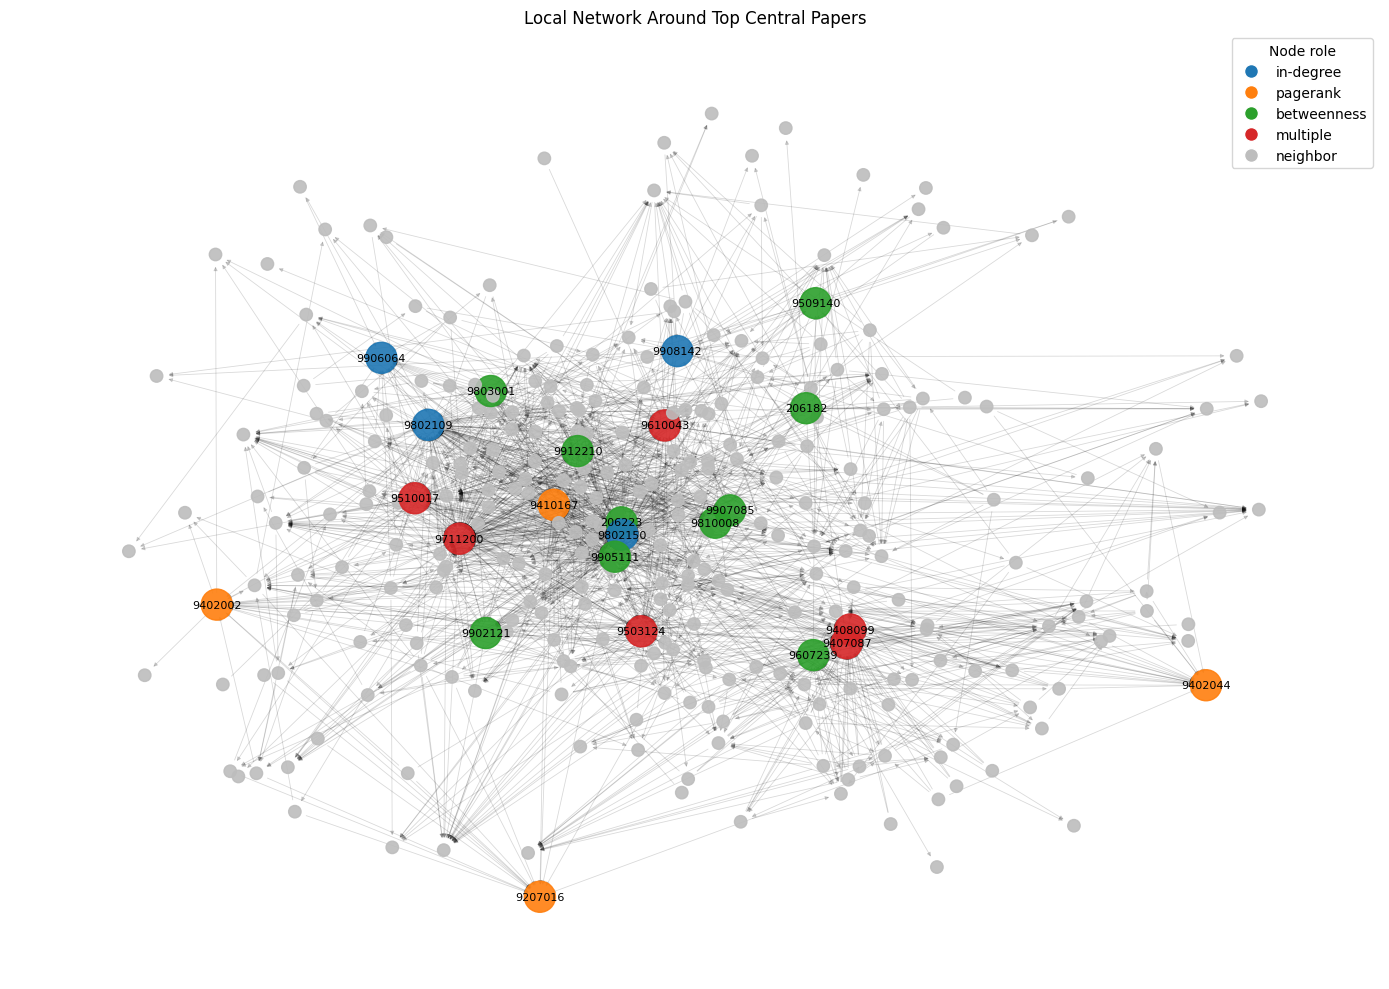

In [32]:
role_to_color = {
    "in-degree": "#1f77b4",
    "pagerank": "#ff7f0e",
    "betweenness": "#2ca02c",
    "multiple": "#d62728",
    "neighbor": "#bdbdbd",
}

node_roles = {
    node: assign_node_role(node)
    for node in central_subgraph.nodes()
}

node_colors = [
    role_to_color[node_roles[node]]
    for node in central_subgraph.nodes()
]

centrality_lookup = centrality_pdf.set_index("node_id").to_dict(orient="index")

node_sizes = []
for node in central_subgraph.nodes():
    if node in important_nodes:
        node_sizes.append(500)
    else:
        node_sizes.append(80)

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(
    central_subgraph,
    seed=42,
    k=0.35,
    iterations=50
)

nx.draw_networkx_edges(
    central_subgraph,
    pos,
    alpha=0.15,
    arrows=True,
    arrowsize=6,
    width=0.6
)

nx.draw_networkx_nodes(
    central_subgraph,
    pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.9
)

labels = {
    node: str(node)
    for node in central_subgraph.nodes()
    if node in important_nodes
}

nx.draw_networkx_labels(
    central_subgraph,
    pos,
    labels=labels,
    font_size=8
)

legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        label=role,
        markerfacecolor=color,
        markersize=10,
    )
    for role, color in role_to_color.items()
]

plt.legend(
    handles=legend_handles,
    title="Node role",
    loc="best"
)

plt.title("Local Network Around Top Central Papers")
plt.axis("off")
plt.tight_layout()

VISUALIZATION_DIR = OUTPUT_DIR / "centrality_analysis" / "figures"
VISUALIZATION_DIR.mkdir(parents=True, exist_ok=True)

plt.savefig(
    VISUALIZATION_DIR / "local_network_top_central_papers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Scatter in-degree vs pageRank

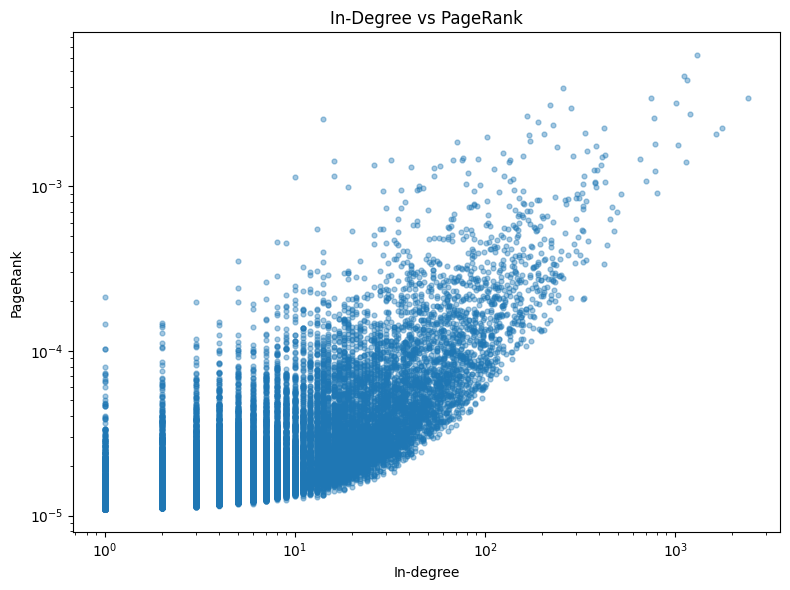

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(
    centrality_pdf["in_degree"],
    centrality_pdf["pagerank"],
    alpha=0.4,
    s=12
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("In-degree")
plt.ylabel("PageRank")
plt.title("In-Degree vs PageRank")

plt.tight_layout()
plt.savefig(
    VISUALIZATION_DIR / "scatter_indegree_vs_pagerank.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Scatter in-degree vs betweenness

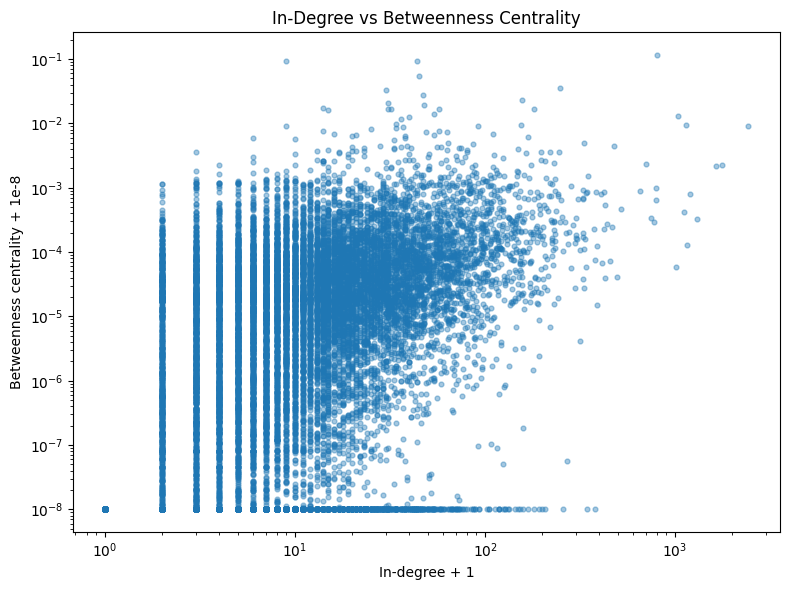

In [34]:
plt.figure(figsize=(8, 6))

plt.scatter(
    centrality_pdf["in_degree"] + 1,
    centrality_pdf["betweenness_centrality"] + 1e-8,
    alpha=0.4,
    s=12
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("In-degree + 1")
plt.ylabel("Betweenness centrality + 1e-8")
plt.title("In-Degree vs Betweenness Centrality")

plt.tight_layout()
plt.savefig(
    VISUALIZATION_DIR / "scatter_indegree_vs_betweenness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Scatter PageRank vs Betweenness

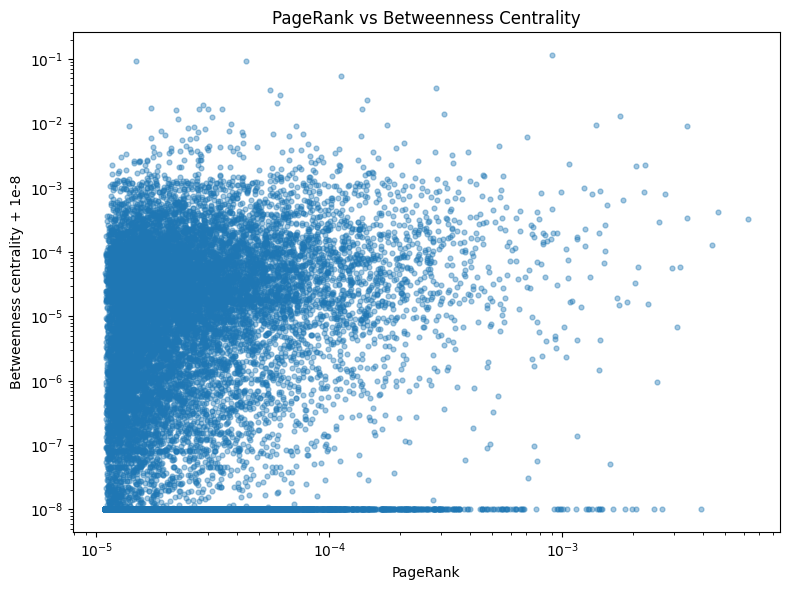

26/05/15 19:42:55 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1057143 ms exceeds timeout 120000 ms
26/05/15 19:42:55 WARN SparkContext: Killing executors is not supported by current scheduler.
26/05/15 19:58:06 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:359)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$

In [35]:
plt.figure(figsize=(8, 6))

plt.scatter(
    centrality_pdf["pagerank"],
    centrality_pdf["betweenness_centrality"] + 1e-8,
    alpha=0.4,
    s=12
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("PageRank")
plt.ylabel("Betweenness centrality + 1e-8")
plt.title("PageRank vs Betweenness Centrality")

plt.tight_layout()
plt.savefig(
    VISUALIZATION_DIR / "scatter_pagerank_vs_betweenness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()